In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import folium
from folium.plugins import HeatMap
from folium.plugins import MarkerCluster

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import warnings

from sklearn.ensemble import RandomForestRegressor

from IPython.display import display

In [12]:

df = pd.read_csv('Map-Crime_Incidents-Previous_Three_Months.csv')
print(len(df))
if 'IncidntNum' in df.columns:
    df = df.drop(columns=['IncidntNum'])
df = df.dropna()
print(len(df))


df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df = df[(df['X'] < -120) & (df['Y'] > 30)]



category_severity = {
    '1': {"NON-CRIMINAL", "SUSPICIOUS OCC", "MISSING PERSON", "RUNAWAY", "SUICIDE"},
    '2': {"LOITERING", "DRUNKENNESS", "LIQUOR LAWS", "GAMBLING", "DISORDERLY CONDUCT"},
    '3': {"TRESPASS", "VANDALISM", "PROSTITUTION", "PORNOGRAPHY/OBSCENE MAT", "BAD CHECKS"},
    '4': {"FRAUD", "FORGERY/COUNTERFEITING", "EMBEZZLEMENT", "OTHER OFFENSES", "WARRANTS"},
    '5': {"LARCENY/THEFT", "VEHICLE THEFT", "STOLEN PROPERTY", "DRUG/NARCOTIC"},
    '6': {"BURGLARY", "DRIVING UNDER THE INFLUENCE", "SEX OFFENSES, NON FORCIBLE"},
    '7': {"WEAPON LAWS", "FAMILY OFFENSES", "BRIBERY", "EXTORTION"},
    '8': {"ROBBERY"},
    '9': {"ASSAULT"},
    '10': {"KIDNAPPING", "SEX OFFENSES, FORCIBLE", "ARSON"}
}

cat_to_score = {}
for score_str, cats in category_severity.items():
    score = int(score_str)
    for c in cats:
        cat_to_score[c] = score

df['Severity'] = df['Category'].map(cat_to_score)
df['Severity'] = df['Severity'].fillna(4)

districts = df['PdDistrict'].dropna().unique()
pd_districts_levels = {d: i for i, d in enumerate(districts)}
df['PdDistrictCode'] = df['PdDistrict'].map(pd_districts_levels)

print("Bűncselekmény súlya:", df['Severity'].mean())


30760
30760
Bűncselekmény súlya: 4.453738621586476


In [13]:
# Bűncselekmény teljes számának becslése n-edik hét + 1 napja

daily_crimes = df.groupby('Date').size().reset_index(name='Count')
daily_crimes = daily_crimes.sort_values('Date')

seq_length = 7
data = daily_crimes['Count'].values
X_rnn, y_rnn = [], []
for i in range(len(data) - seq_length):
    X_rnn.append(data[i:i+seq_length])
    y_rnn.append(data[i+seq_length])
    
X_rnn, y_rnn = np.array(X_rnn), np.array(y_rnn)
X_rnn = np.reshape(X_rnn, (X_rnn.shape[0], X_rnn.shape[1], 1))

max_val = np.max(data)
X_rnn_scaled = X_rnn / max_val
y_rnn_scaled = y_rnn / max_val

tf.random.set_seed(42)
rnn_model = Sequential([
    SimpleRNN(64, activation='sigmoid', input_shape=(seq_length, 1)),
    Dropout(0.2),
    Dense(32, activation='sigmoid'),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_rnn_scaled, y_rnn_scaled, epochs=50, batch_size=4, verbose=0)

last_7_days = data[-seq_length:]
last_7_days_scaled = (last_7_days / max_val).reshape(1, seq_length, 1)
predicted_count_scaled = rnn_model.predict(last_7_days_scaled, verbose=0)[0][0]
predicted_crimes_tomorrow = int(predicted_count_scaled * max_val)
print(f"Holnap {predicted_crimes_tomorrow} bűncselekmény történik összesen.")




c:\Users\Máté\Documents\Modern Ipari Techn\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Holnap 324 bűncselekmény történik összesen.


In [14]:
# markov lánc
df_sorted = df.sort_values(by=['Date', 'Time'])

# P(C_t | C_{t-1})
df_sorted['Next_Category'] = df_sorted['Category'].shift(-1)


transitions = pd.crosstab(df_sorted['Category'], df_sorted['Next_Category'], normalize='index')




In [15]:
# bayes tétel: helyszínek prediktálására

# Prior: P(District)
p_district = df['PdDistrict'].value_counts(normalize=True).to_dict()

# Likelihood: P(Category, Hour | District)
likelihoods = {}
for dist in df['PdDistrict'].unique():
    dist_data = df[df['PdDistrict'] == dist]
    # Sima gyakoriság
    dist_cat_hour = dist_data.groupby(['Category', 'Hour']).size() / len(dist_data)
    likelihoods[dist] = dist_cat_hour.to_dict()

def predict_district_bayes(category, hour):
    posteriors = {}
    
    #Teljes val. a nevezőbe
    # Sum(P(C,H | D) * P(D)) minden D körzetre
    marginal = 0
    for dist in p_district.keys():
        like = likelihoods[dist].get((category, hour), 1e-6) # Laplace smoothing szerű pici esély
        marginal += like * p_district[dist]
        
    for dist in p_district.keys():
        like = likelihoods[dist].get((category, hour), 1e-6)
        prior = p_district[dist]
        
        # Bayes tétel: P(D | C, H) = P(C, H | D) * P(D) / P(C, H)
        posteriors[dist] = (like * prior) / marginal
        
        
    return max(posteriors, key=posteriors.get)




In [16]:
features = ['X', 'Y', 'Hour', 'PdDistrictCode']
target = 'Severity'

X_train = df[features].dropna()
y_train = df.loc[X_train.index, target]

rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [17]:
current_cat = df_sorted['Category'].iloc[-1]
predicted_events = []

for _ in range(predicted_crimes_tomorrow):
    # Bűncselekmény típusa:
    if current_cat in transitions.index:
        next_cat_probs = transitions.loc[current_cat]
        # bűncselekmény súlya
        next_cat = np.random.choice(next_cat_probs.index, p=next_cat_probs.values)
    else:
        next_cat = np.random.choice(df['Category'].unique())
    
    # időpont
    cat_data = df[df['Category'] == next_cat]
    if len(cat_data) > 0:
        hour = np.random.choice(cat_data['Hour'])
    else:
        hour = np.random.randint(0, 24)
        
    # helye
    predicted_dist = predict_district_bayes(next_cat, hour)
    
    # adott körzeten belül
    dist_coords = df[df['PdDistrict'] == predicted_dist][['Y', 'X']].dropna().values
    if len(dist_coords) > 0:
        base_coord = dist_coords[np.random.randint(0, len(dist_coords))]
        
        
        lat = base_coord[0] + np.random.normal(0, 0.002)
        lon = base_coord[1] + np.random.normal(0, 0.002)
    else:
        lat, lon = 37.77, -122.42
        
    
    # kockázati szint:
    dist_code = pd_districts_levels.get(predicted_dist, 0)

    pred_features = pd.DataFrame({'X': [lon], 'Y': [lat], 'Hour': [hour], 'PdDistrictCode': [dist_code]})
    predicted_severity = rf_model.predict(pred_features)[0]
    
    predicted_events.append({
        'Category': next_cat, 
        'Hour': hour, 
        'PdDistrict': predicted_dist, 
        'Y': lat, 
        'X': lon,
        'Predicted_Severity': predicted_severity
    })
    
    
    # állapot frissítése
    current_cat = next_cat

pred_df = pd.DataFrame(predicted_events)




In [18]:
m_tomorrow = folium.Map(location=[37.77, -122.42], zoom_start=12, tiles='CartoDB Dark_Matter')

HeatMap(
    pred_df[['Y', 'X']].values, 
    radius=14, 
    blur=10, 
    gradient={0.2: 'blue', 0.5: 'yellow', 1.0: 'red'}
).add_to(m_tomorrow)


marker_cluster = MarkerCluster().add_to(m_tomorrow)

for idx, row in pred_df.iterrows():
    sev = row.get('Predicted_Severity', 4.0)
    
    if sev < 4.0:
        marker_color = 'green'
        icon_type = 'info-sign'
    elif sev < 8.0:
        marker_color = 'orange'
        icon_type = 'warning-sign'
    else:
        marker_color = 'darkred'
        icon_type = 'exclamation-sign'
        
    folium.Marker(
        location=[row['Y'], row['X']],
        popup=folium.Popup(f"<b>VÁRHATÓ: {row['Category']}</b><br>Kockázati szint: <b>{sev:.1f}/10</b><br>Idő: {row['Hour']}:00 - {row['Hour']+1}:00<br>Körzet: {row['PdDistrict']}", max_width=250),
        icon=folium.Icon(color=marker_color, icon=icon_type)
    ).add_to(marker_cluster)

m_tomorrow


Összesen 9 anomáliás napot találtunk a kerületekben.


,Date,PdDistrict,Count,Rolling_Mean,Rolling_Std,Is_Anomaly
62,2014-06-07 07:00:00+00:00,INGLESIDE,45,30.857143,7.010197,True
152,2014-06-16 07:00:00+00:00,INGLESIDE,41,28.000000,6.218253,True
273,2014-06-28 07:00:00+00:00,MISSION,82,49.428571,15.778225,True
354,2014-07-06 07:00:00+00:00,NORTHERN,53,37.428571,7.634508,True
508,2014-07-21 07:00:00+00:00,TARAVAL,47,24.571429,11.088389,True
543,2014-07-25 07:00:00+00:00,MISSION,61,44.714286,7.889112,True
803,2014-08-20 07:00:00+00:00,MISSION,63,48.714286,6.945365,True
824,2014-08-22 07:00:00+00:00,NORTHERN,49,35.571429,6.451283,True
835,2014-08-23 07:00:00+00:00,PARK,35,20.571429,6.924766,True


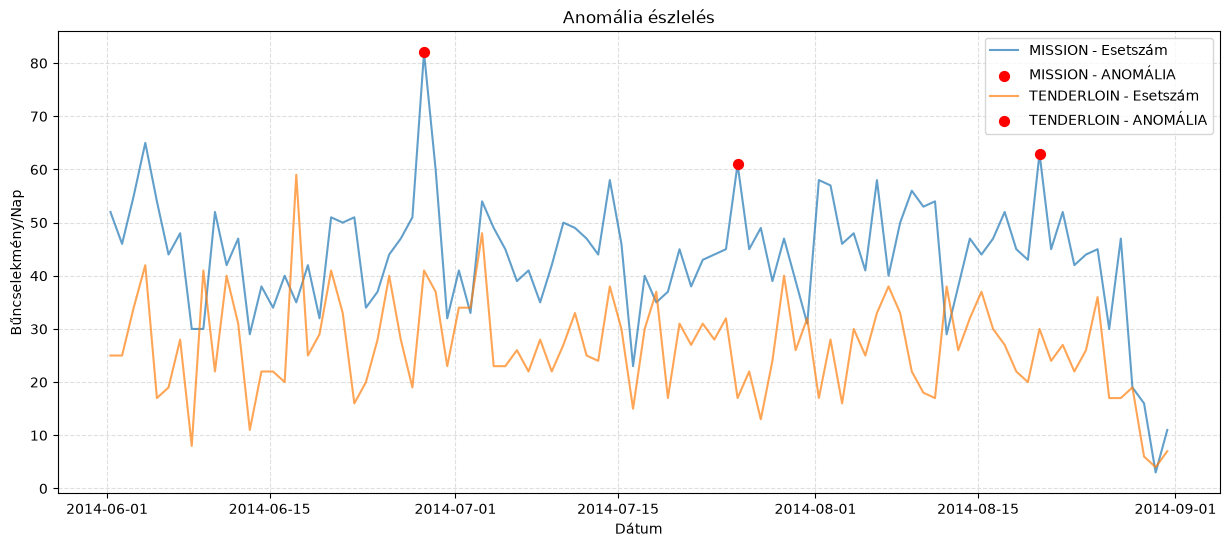

C:\Users\Máté\AppData\Local\Temp\ipykernel_16288\2746538564.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PdDistrict', y='Count', data=daily_dist_crimes, palette='viridis')
c:\Users\Máté\Documents\Modern Ipari Techn\venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\Máté\Documents\Modern Ipari Techn\venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\Máté\Documents\Modern Ipari Techn\venv\Lib\site-packages\seaborn\categorical.py:700: Ma

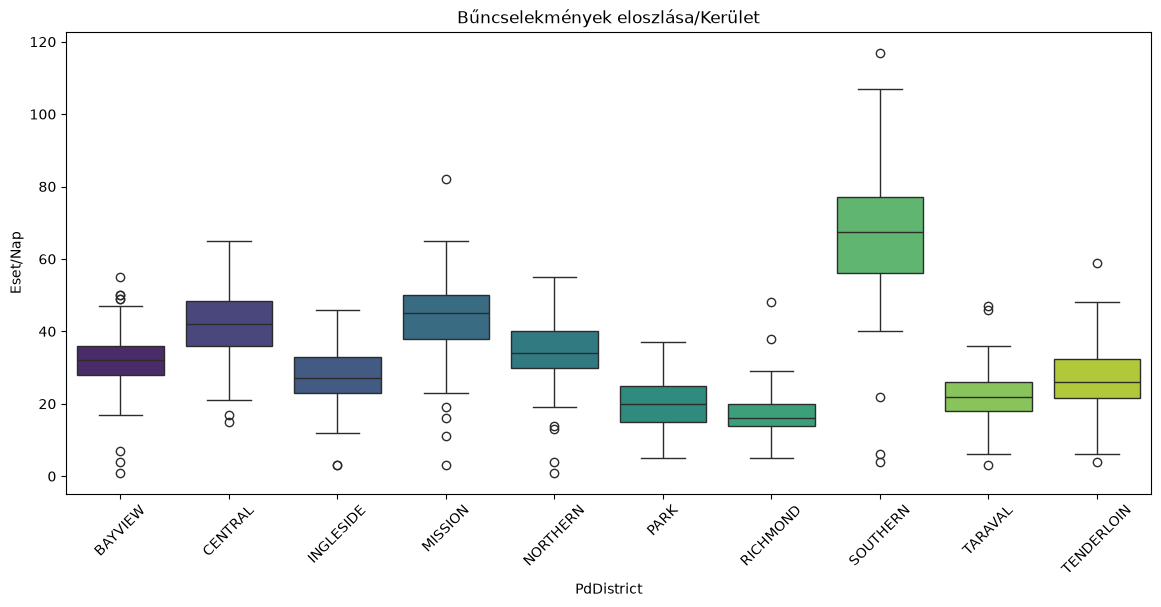

In [19]:

# Eset db kerületenként
daily_dist_crimes = df.groupby(['Date', 'PdDistrict']).size().reset_index(name='Count')

# SMA
daily_dist_crimes['Rolling_Mean'] = daily_dist_crimes.groupby('PdDistrict')['Count'].transform(lambda x: x.rolling(7, min_periods=1).mean())
daily_dist_crimes['Rolling_Std'] = daily_dist_crimes.groupby('PdDistrict')['Count'].transform(lambda x: x.rolling(7, min_periods=1).std().fillna(0))

# napi db > atlag + 2 * szórás

daily_dist_crimes['Is_Anomaly'] = daily_dist_crimes['Count'] > (daily_dist_crimes['Rolling_Mean'] + 2 * daily_dist_crimes['Rolling_Std'])
anomalies = daily_dist_crimes[daily_dist_crimes['Is_Anomaly']]

print(f"Összesen {len(anomalies)} anomáliás napot találtunk a kerületekben.")

# Anomáliás rekordok megjelenítése
display(anomalies)


# Vizualizáció: Anomáliák ábrázolása a 'MISSION' és 'TENDERLOIN' kerületekre példaként
plt.figure(figsize=(15, 6))
sample_districts = ['MISSION', 'TENDERLOIN']

for dist in sample_districts:
    dist_data = daily_dist_crimes[daily_dist_crimes['PdDistrict'] == dist]
    dist_anomalies = dist_data[dist_data['Is_Anomaly']]
    
    plt.plot(dist_data['Date'], dist_data['Count'], label=f'{dist} - Esetszám', alpha=0.7)

    plt.scatter(dist_anomalies['Date'], dist_anomalies['Count'], color='red', s=50, zorder=5, label=f'{dist} - ANOMÁLIA')

plt.title('Anomália észlelés')
plt.xlabel('Dátum')
plt.ylabel('Bűncselekmény/Nap')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


plt.figure(figsize=(14, 6))
sns.boxplot(x='PdDistrict', y='Count', data=daily_dist_crimes, palette='viridis')
plt.title('Bűncselekmények eloszlása/Kerület')
plt.xticks(rotation=45)
plt.ylabel('Eset/Nap')
plt.show()
